In [1]:
from xcube_resampling import __version__ as version

version

'0.3.0.dev0'

In [2]:
from xcube import __version__ as version

version

'1.13.1'

In [3]:
import xarray as xr
from xcube.core.resampling import rectify_dataset
from xcube.core.gridmapping import GridMapping
from xcube_resampling import rectify_dataset as rectify_dataset_new 
import matplotlib.pyplot as plt
import numpy as np

In [4]:
source_ds = xr.open_zarr("./data/S3-OLCI-L2A.zarr.zip", consolidated=False)

In [5]:
%%time
target_ds = rectify_dataset_new(source_ds, interp_methods="nearest")
target_ds

CPU times: user 1.05 s, sys: 143 ms, total: 1.19 s
Wall time: 1 s


<xarray.Dataset> Size: 56MB
Dimensions:        (lon: 1636, lat: 2132)
Coordinates:
  * lon            (lon) float64 13kB 12.69 12.7 12.7 12.71 ... 20.0 20.0 20.0
  * lat            (lat) float64 17kB 60.64 60.64 60.63 ... 55.21 55.2 55.2
    spatial_ref    int64 8B 0
Data variables:
    quality_flags  (lat, lon) uint32 14MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    rtoa_3         (lat, lon) float32 14MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    rtoa_6         (lat, lon) float32 14MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    rtoa_8         (lat, lon) float32 14MB dask.array<chunksize=(512, 512), meta=np.ndarray>
Attributes:
    Conventions:   CF-1.4
    product_type:  C2RCC_OLCI
    start_date:    04-JUL-2018 09:21:55.677316
    stop_date:     04-JUL-2018 09:23:18.811790

In [6]:
%%time
target_gm = GridMapping.from_coords(target_ds.lon, target_ds.lat, crs="EPSG:4326")
target_gm

CPU times: user 41.6 ms, sys: 180 μs, total: 41.8 ms
Wall time: 40.3 ms


class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.004471325, 0.00255235)
* xy_bbox: (12.6920652975, 55.1989038, 20.007144802499997, 60.640514)
* ij_bbox: (0, 0, 1636, 2132)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (1636, 2132)
* tile_size: (1636, 2132)

In [7]:
%%time
target_ds_new = rectify_dataset(source_ds, target_gm=target_gm, interpolation="nearest")
target_ds_new

CPU times: user 6.12 s, sys: 525 ms, total: 6.65 s
Wall time: 3.09 s


<xarray.Dataset> Size: 56MB
Dimensions:        (lat: 2132, lon: 1636, bnds: 2)
Coordinates:
  * lat            (lat) float64 17kB 60.64 60.64 60.63 ... 55.21 55.2 55.2
  * lon            (lon) float64 13kB 12.69 12.7 12.7 12.71 ... 20.0 20.0 20.0
    lon_bnds       (lon, bnds) float64 26kB 12.69 12.7 12.7 ... 20.0 20.0 20.01
    lat_bnds       (lat, bnds) float64 34kB 60.64 60.64 60.64 ... 55.2 55.2 55.2
Dimensions without coordinates: bnds
Data variables:
    quality_flags  (lat, lon) uint32 14MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    rtoa_3         (lat, lon) float32 14MB nan nan nan nan ... nan nan nan nan
    rtoa_6         (lat, lon) float32 14MB nan nan nan nan ... nan nan nan nan
    rtoa_8         (lat, lon) float32 14MB nan nan nan nan ... nan nan nan nan
Attributes:
    Conventions:   CF-1.4
    product_type:  C2RCC_OLCI
    start_date:    04-JUL-2018 09:21:55.677316
    stop_date:     04-JUL-2018 09:23:18.811790

CPU times: user 28.5 s, sys: 4.16 s, total: 32.6 s
Wall time: 5.48 s


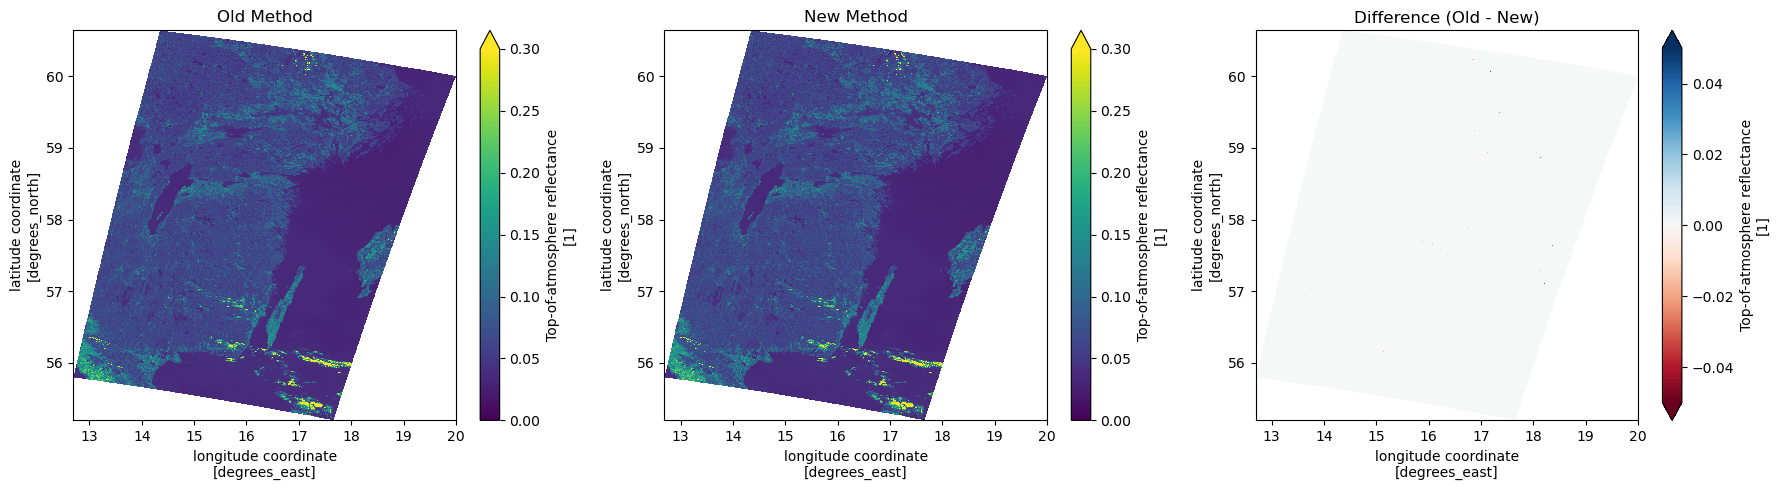

In [8]:
%%time
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
target_ds.rtoa_8.plot(ax=ax[0], vmin=0., vmax=0.3)
ax[0].set_title("Old Method")
target_ds_new.rtoa_8.plot(ax=ax[1], vmin=0., vmax=0.3)
ax[1].set_title("New Method")
(target_ds - target_ds_new).rtoa_8.plot(ax=ax[2], vmin=-0.05, vmax=0.05, cmap="RdBu")
ax[2].set_title("Difference (Old - New)")
plt.tight_layout()

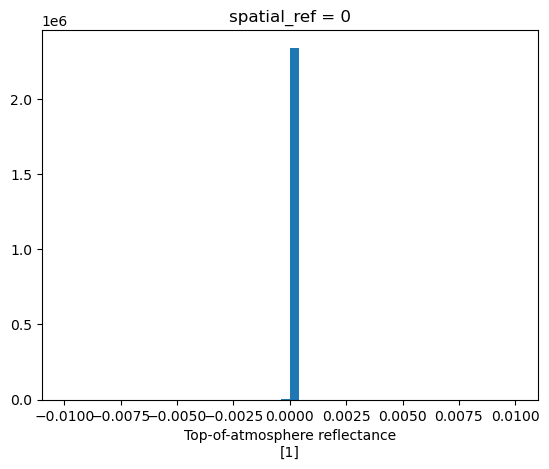

In [9]:
result = (target_ds - target_ds_new).rtoa_8.plot.hist(bins=50, range=(-0.01, 0.01))

CPU times: user 1.64 s, sys: 74.5 ms, total: 1.71 s
Wall time: 1.14 s


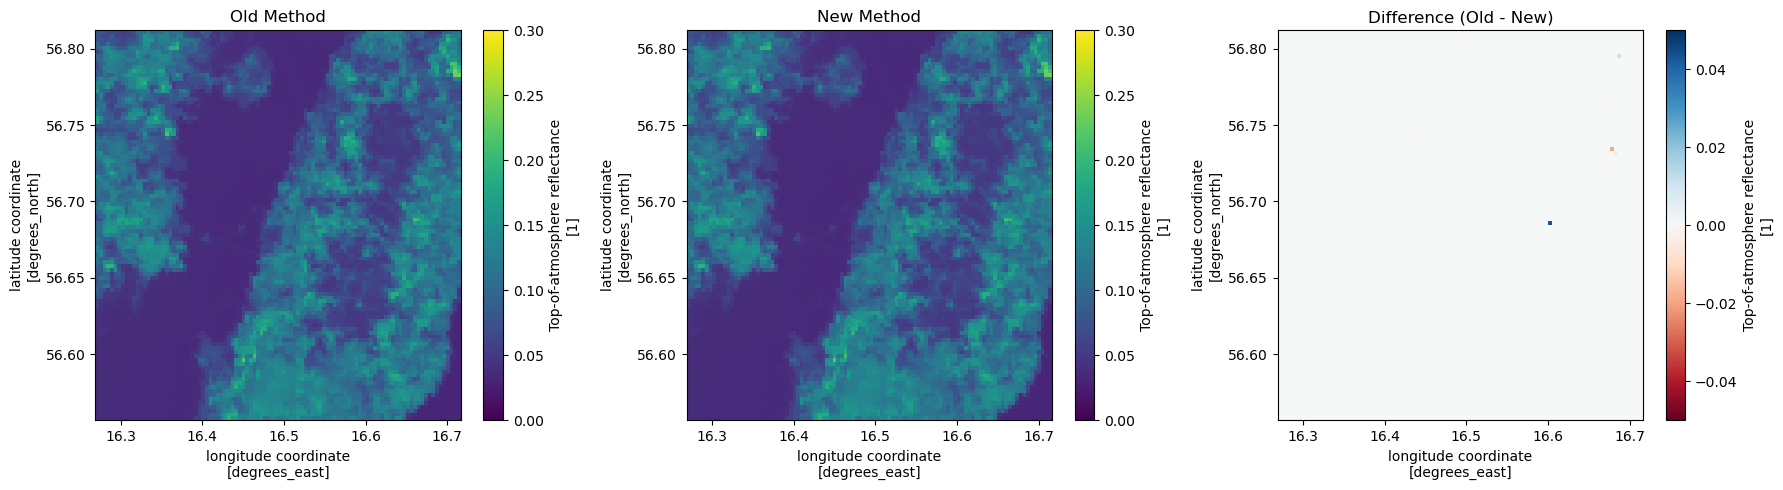

In [10]:
%%time
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
target_ds.rtoa_8[1500:1600, 800:900].plot(ax=ax[0], vmin=0., vmax=0.3)
ax[0].set_title("Old Method")
target_ds_new.rtoa_8[1500:1600, 800:900].plot(ax=ax[1], vmin=0., vmax=0.3)
ax[1].set_title("New Method")
(target_ds - target_ds_new).rtoa_8[1500:1600, 800:900].plot(ax=ax[2], vmin=-0.05, vmax=0.05, cmap="RdBu")
ax[2].set_title("Difference (Old - New)")
plt.tight_layout()